# Project Name: Wine classification

# About Data Set
The Wine Quality Dataset, originating from the UCI Machine Learning Repository, is a popular benchmark for classification and regression, containing 6,497 samples of Portuguese "Vinho Verde" (red and white). It features 11 physicochemical inputs (acidity, pH, alcohol, etc.) to predict wine quality scores (0-10) or type.

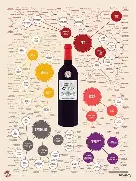

In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [19]:
from sklearn.datasets import load_wine
wine=load_wine()

In [20]:
df = pd.DataFrame(wine.data,columns=wine.feature_names)

In [21]:
df["Target"] = wine.target

In [22]:
df.sample(6)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
156,13.84,4.12,2.38,19.5,89.0,1.80,0.83,0.48,1.56,9.01,0.57,1.64,480.0,2
117,12.42,1.61,2.19,22.5,108.0,2.00,2.09,0.34,1.61,2.06,1.06,2.96,345.0,1
77,11.84,2.89,2.23,18.0,112.0,1.72,1.32,0.43,0.95,2.65,0.96,2.52,500.0,1
119,12.00,3.43,2.00,19.0,87.0,2.00,1.64,0.37,1.87,1.28,0.93,3.05,564.0,1
84,11.84,0.89,2.58,18.0,94.0,2.20,2.21,0.22,2.35,3.05,0.79,3.08,520.0,1
168,13.58,2.58,2.69,24.5,105.0,1.55,0.84,0.39,1.54,8.66,0.74,1.80,750.0,2


<Axes: >

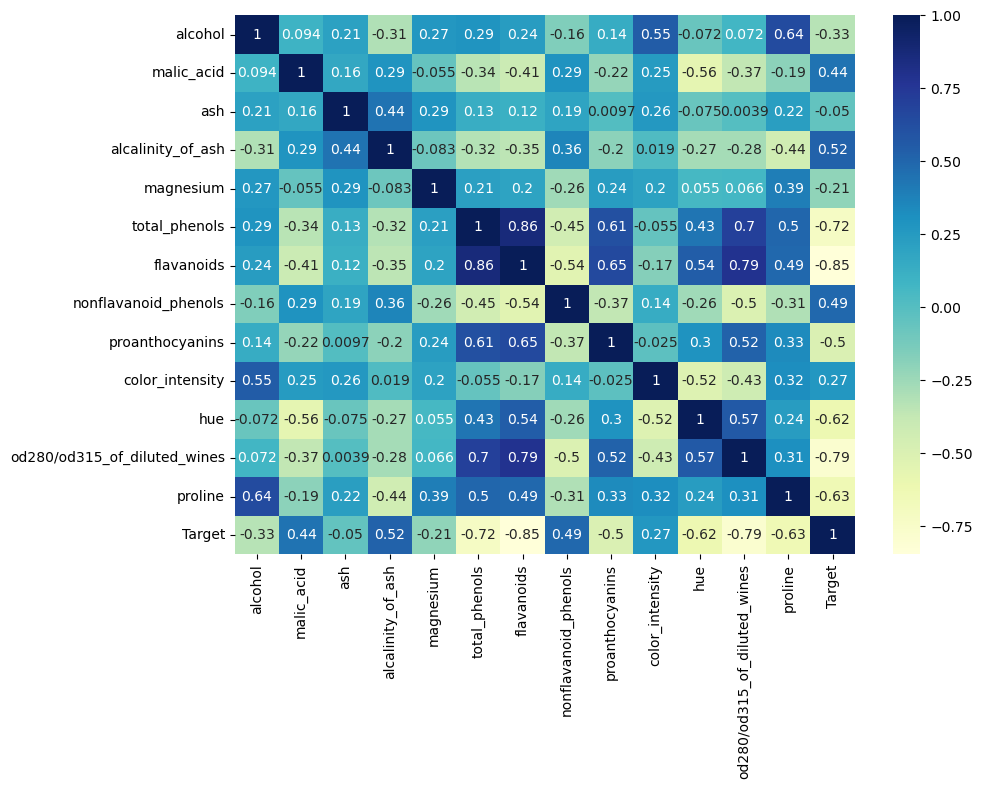

In [23]:
plt.figure(figsize=(10,7))
corr = df[df.columns].corr()
sns.heatmap(corr, cmap="YlGnBu", annot = True)

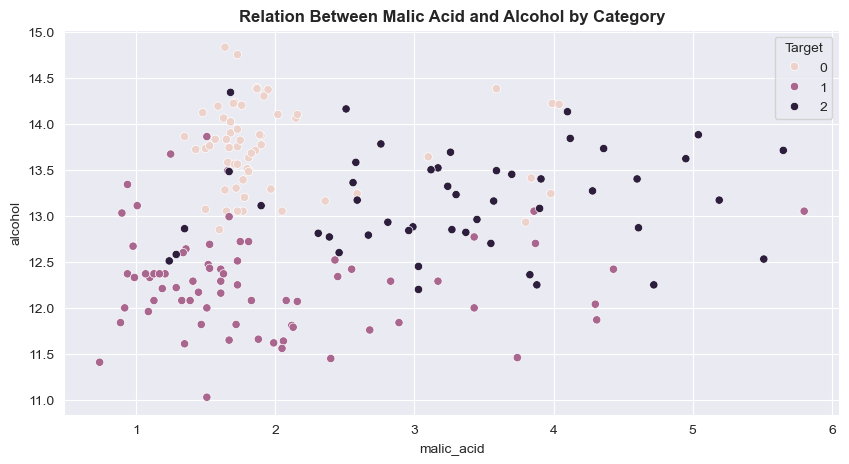

In [24]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")
sns.scatterplot(data=df,x="malic_acid",y="alcohol",hue="Target")
plt.title("Relation Between Malic Acid and Alcohol by Category",fontweight="bold")
plt.show()

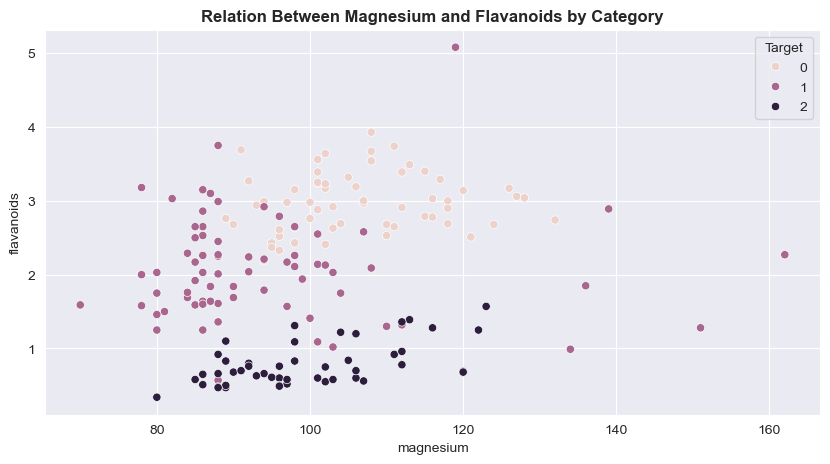

In [26]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")
sns.scatterplot(data=df,x="magnesium",y="flavanoids",hue="Target")
plt.title("Relation Between Magnesium and Flavanoids by Category",fontweight="bold")
plt.show()

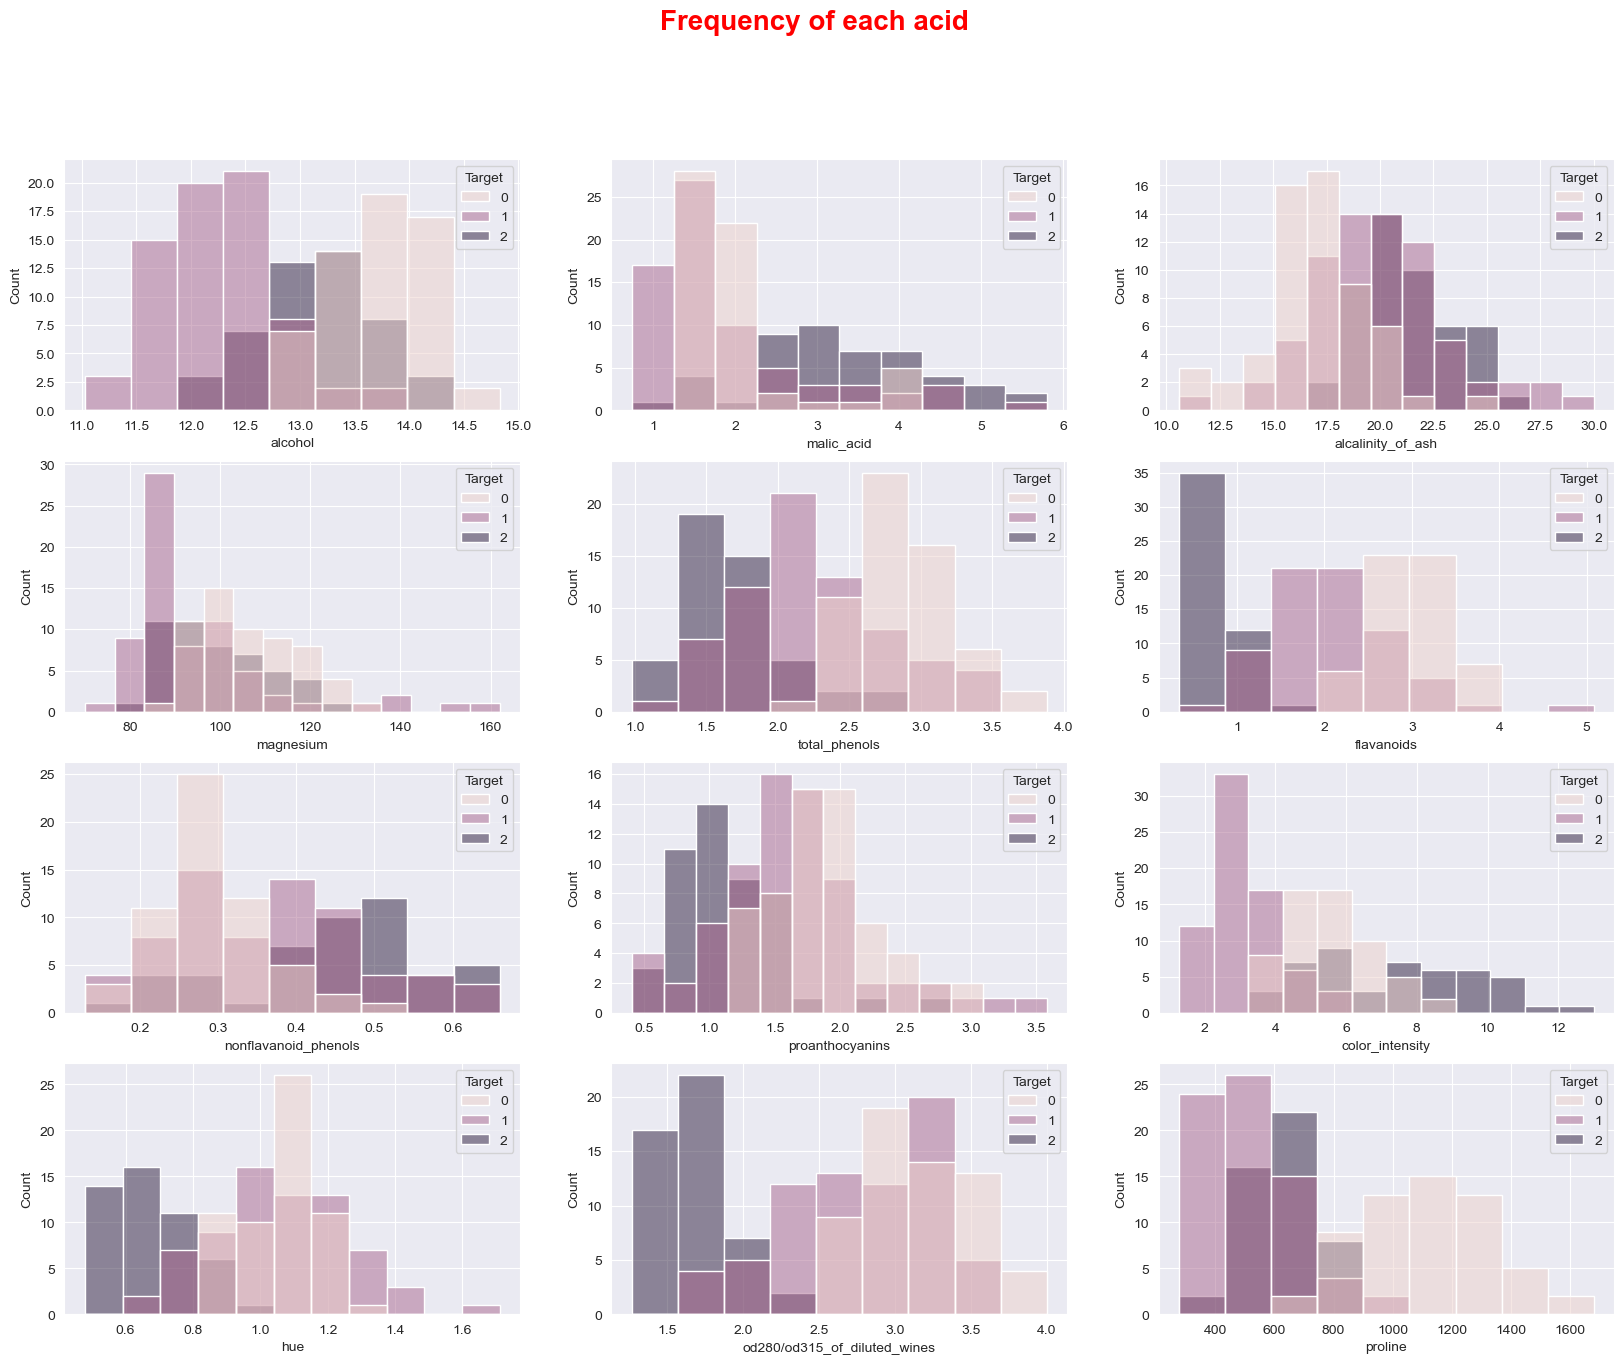

In [29]:
plt.figure(figsize=(20,15))
c = 1
for i in df:
    if i=="Target" or i=="ash":
        continue
    else:
        plt.subplot(4,3,c)
        sns.histplot(data=df,x=i,hue="Target")
        c+=1
plt.suptitle("Frequency of each acid",fontweight="bold",fontsize=20,color="red")
plt.show()

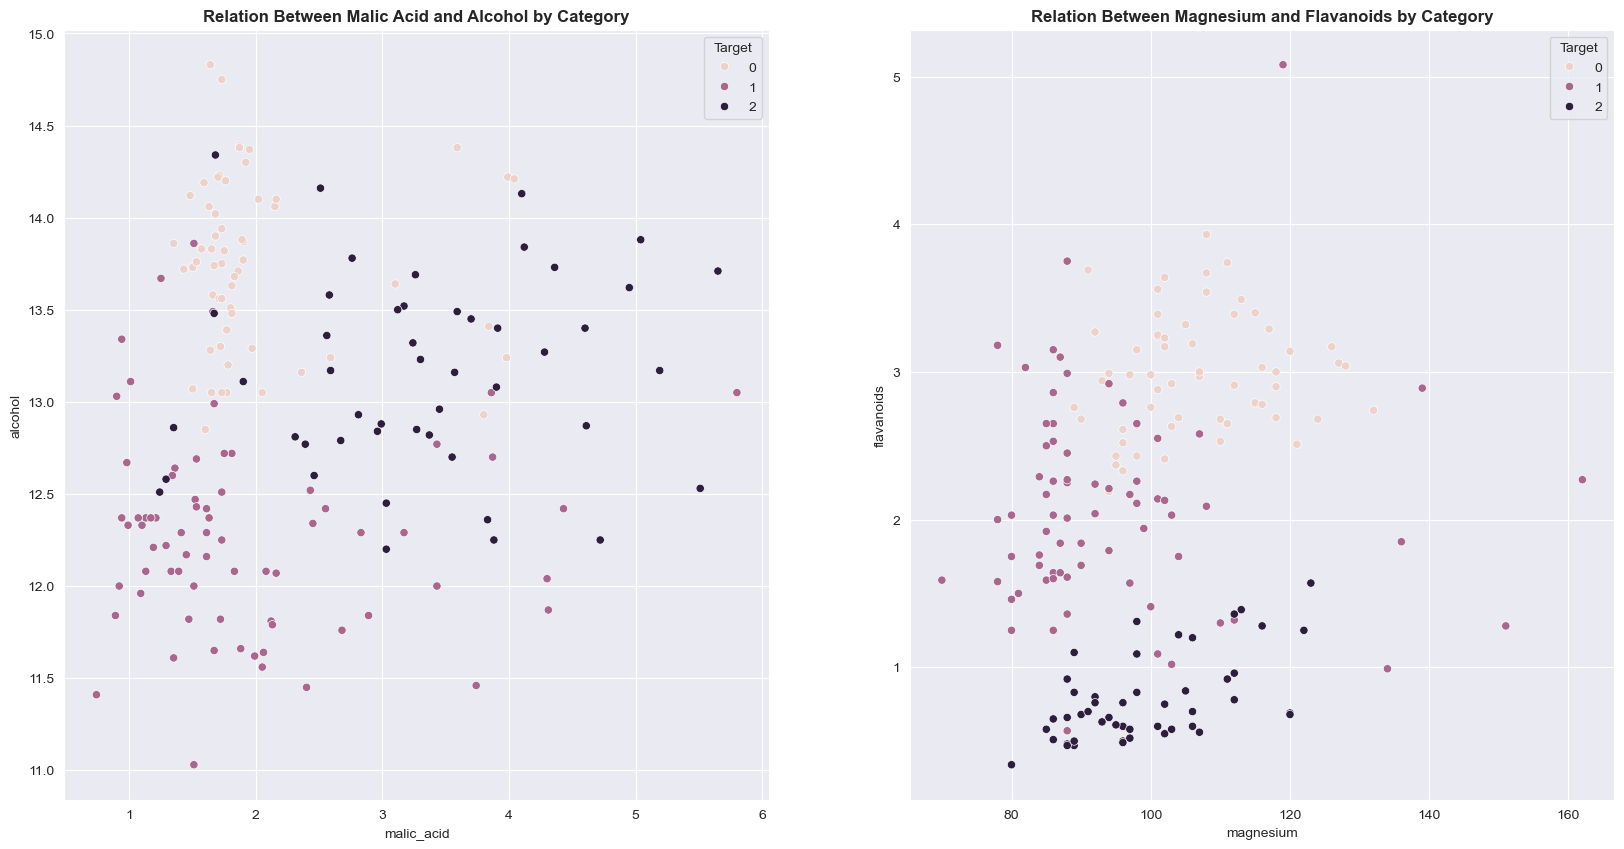

In [30]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.scatterplot(data=df,x="malic_acid",y="alcohol",hue="Target")
plt.title("Relation Between Malic Acid and Alcohol by Category",fontweight="bold")
plt.subplot(1,2,2)
sns.scatterplot(data=df,x="magnesium",y="flavanoids",hue="Target")
plt.title("Relation Between Magnesium and Flavanoids by Category",fontweight="bold")
plt.show()

# Extract Features and target in x an y

In [32]:
x = df.drop("Target",axis=1)
y = df[["Target"]]

In [33]:
# splitting the data from training and testing 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=50)

print("-"*50)
print("Total Number of Rows for training is : ",x_train.shape[0])
print("-"*50)
print("Total Number of Rows for testing  : ",x_test.shape[0])
print("-"*50)

--------------------------------------------------
Total Number of Rows for training is :  142
--------------------------------------------------
Total Number of Rows for testing  :  36
--------------------------------------------------


In [34]:
# Normalize the dataset with the help of standard scalling
st = StandardScaler()
x_train_sc = st.fit_transform(x_train)
x_test_sc = st.transform(x_test)

### **Building the machine learning Model**

In [35]:
log = LogisticRegression()

# training the machine learning Model
log.fit(x_train_sc,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
pred = log.predict(x_test_sc)

In [37]:
ac = log.score(x_train_sc,y_train)
ac2 = log.score(x_test_sc,y_test)

In [38]:
print("-"*60)
print("Accuracy of Training Data : ",ac)
print("-"*60)
print("Accuracy of test data :",ac2)
print("-"*60)

------------------------------------------------------------
Accuracy of Training Data :  1.0
------------------------------------------------------------
Accuracy of test data : 1.0
------------------------------------------------------------


In [39]:
print("_______Final Prediction_______")
print("-"*90)
print(pred)
print("-"*90)

_______Final Prediction_______
------------------------------------------------------------------------------------------
[1 1 1 2 2 2 1 1 0 2 0 0 1 0 1 2 1 2 1 0 0 1 0 2 0 0 1 1 0 1 0 0 2 2 0 1]
------------------------------------------------------------------------------------------


## **Model Evaluation**

In [40]:
cv = confusion_matrix(pred,y_test)
print(cv)

[[13  0  0]
 [ 0 14  0]
 [ 0  0  9]]


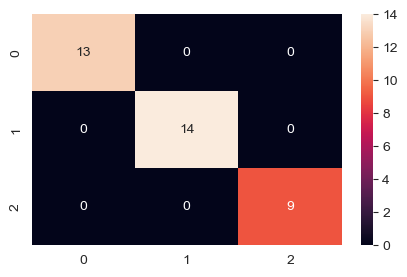

In [41]:
plt.figure(figsize=(5,3))
sns.heatmap(cv,annot=True);